In [1]:
"""
Robbins-Monro (RM) algorithm applied to finding the root of
    g(w) = tanh(w - 1)
whose true root is 1.0.

Noisy observation: g_tilde(w, eta) = g(w) + eta,  eta ~ N(0, 1)
Initial guess: w_1 = 3.0 
Step size:     a_k = 1/k
"""

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── Reproducibility ──────────────────────────────────────────────
np.random.seed(6)

# ── Parameters ───────────────────────────────────────────────────
K       = 50   # number of iterations shown
w_true  = 1    # true root = 1

In [3]:
# ── Run RM algorithm ─────────────────────────────────────────────
def g(w):
    #return w**3 - 5
    return np.tanh(w - 1.)

noise = 1.0*np.random.randn(K + 1)   # eta_k, indices 1..K
w = np.zeros(K + 1)
w[1] = 3.0 #1.5                        # initial guess

for k in range(1, K):
    a_k      = 1.0 / k
    g_tilde  = g(w[k]) + noise[k]
    #print(g_tilde)
    w[k + 1] = w[k] - a_k * g_tilde
    #print(w[k+1])
    #print(5*'-')

iterations = np.arange(1, K + 1)
w_plot     = w[1 : K + 1]
eta_plot   = noise[1 : K + 1]

True root: 1.0000 | Final estimate w_50 = 0.9726


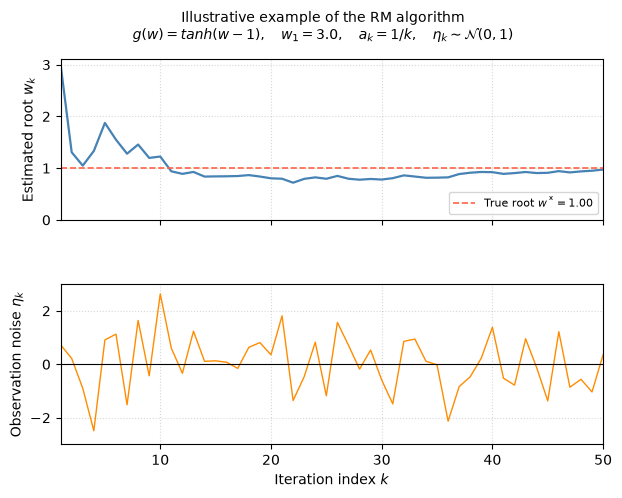

In [4]:
# ── Plot ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
fig.subplots_adjust(hspace=0.4)

# --- Top subplot: estimated root ---
ax1.plot(iterations, w_plot, color="steelblue", linewidth=1.6)
ax1.axhline(w_true, color="tomato", linestyle="--", linewidth=1.2,
            label=f"True root $w^* = {w_true:.2f}$")
ax1.set_ylabel("Estimated root $w_k$")
ax1.set_xlim(1, K)
ax1.set_ylim(0, 3.1)
ax1.set_yticks([0, 1, 2, 3])
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(True, linestyle=":", alpha=0.5)

# --- Bottom subplot: observation noise ---
ax2.plot(iterations, eta_plot, color="darkorange", linewidth=1.0)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Iteration index $k$")
ax2.set_ylabel("Observation noise $\\eta_k$")
ax2.set_xlim(1, K)
ax2.set_ylim(-3, 3)
ax2.set_yticks([-2, 0, 2])
ax2.grid(True, linestyle=":", alpha=0.5)

fig.suptitle(
    "Illustrative example of the RM algorithm\n"
    r"$g(w)=tanh(w - 1),\quad w_1=3.0,\quad a_k=1/k,\quad \eta_k\sim\mathcal{N}(0,1)$",
    fontsize=10
)

plt.savefig("figure_6_3.png", dpi=150, bbox_inches="tight")
print(f"True root: {w_true:.4f} | Final estimate w_50 = {w[K]:.4f}")